# Chapter 08: Viewing

Source orientation: printed pages 157-176; physical PDF pages 174-193. This notebook uses that span only to choose the mathematical coverage: viewing transformations, viewport mapping, orthographic projection, camera coordinates, projective homogeneous division, perspective matrices, line preservation, and field-of-view. The prose, code, diagrams, and checks below are original course material.

## Chapter question

How does a renderer move a point from a 3D world into a 2D pixel position without hiding the geometry inside one mysterious matrix?

The source chapter's central move is to factor viewing into understandable transformations. A model point is first described in world coordinates, then in camera coordinates, then in a canonical view volume, and finally in screen pixels. Perspective adds one extra idea: a matrix can change the homogeneous coordinate, and the final divide by `w` creates the familiar `1/z` size change. The notebook keeps those pieces visible so each row of the matrix has a job the learner can inspect.

## Translation guide

- **World to camera**: build an orthonormal camera basis from an eye point `e`, gaze vector `g`, and view-up vector `t`; then translate the eye to the origin and rotate into `u,v,w` coordinates.
- **Camera to canonical volume**: use either an orthographic window map or a perspective frustum map. Both end in the cube `[-1,1]^3`.
- **Canonical to pixels**: use a viewport transform from canonical `x,y` to pixel centers, while carrying a normalized depth value for later hidden-surface work.
- **Projective coordinates**: treat a homogeneous vector `[x,y,z,w]` as the Cartesian point `(x/w,y/w,z/w)` whenever `w` is nonzero. Scalar multiples describe the same point.
- **Field of view**: replace an arbitrary near-plane window with `t = |n| tan(theta/2)` and `r/t = nx/ny` when centered pixels should be square.

## Visual storyboard and library routing

| Order | Artifact | Concept | Representation | Library | Inspection target | Check |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | `viewing-transform-chain.png` | world, camera, canonical, screen spaces | stage diagram | Matplotlib | where each matrix enters the product | stage count and matrix order |
| 2 | `viewport-orthographic-window-map.png` | canonical cube and orthographic box mapping | paired window diagrams | Matplotlib | corners and depth endpoints | endpoint coordinate assertions |
| 3 | `camera-uvw-basis-frustum.png` | camera construction from `e,g,t` | 3D frame/frustum diagram | Matplotlib 3D | orthonormal `u,v,w`, gaze opposite `w` | dot products, determinant, eye-to-origin |
| 4 | `homogeneous-projective-square-map.png` | projective transforms and homogeneous scale equivalence | square-to-quadrilateral homography | Matplotlib | lines remain lines, parallels need not | scalar-equivalence residual |
| 5 | `perspective-frustum-depth-map.png` | perspective matrix and nonlinear depth | frustum/depth diagnostic | Matplotlib | near/far planes and depth monotonicity | frustum corner and depth-order checks |
| 6 | `line-preservation-homogeneous-divide.png` | perspective maps line segments to line segments | sampled segment before/after | Matplotlib | post-divide samples lie on one line | area residual and monotone parameter |
| 7 | `field-of-view-frustum-lab.html` | FOV, aspect ratio, and near-plane window | interactive Plotly surface | Plotly | how vertical angle and aspect set width/height | formula and monotonicity checks |

The chapter is complete only if the reader can connect every matrix in the product `Mvp Morth P Mcam` to a visible geometric action and a reproducible invariant.


In [1]:
from pathlib import Path
import math
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the FCG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon, Rectangle
import numpy as np
import plotly.graph_objects as go

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html, save_table_csv
from utils.notebook_checks import assert_nonblank_image

CHAPTER = 8
TITLE = "Viewing"
UNIT = f"chapter-{CHAPTER:02d}"
SOURCE_SPAN = "printed pages 157-176; physical PDF pages 174-193"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
for child in ["figures", "html", "tables", "checks"]:
    (ARTIFACT_ROOT / child).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 170, "font.size": 10})
COLORS = {
    "blue": "#2b6cb0",
    "teal": "#008080",
    "orange": "#d97706",
    "red": "#c53030",
    "green": "#2f855a",
    "purple": "#6b46c1",
    "gray": "#4a5568",
    "light": "#edf2f7",
}

image_paths = []
html_paths = []
table_paths = []
check_paths = []
checks = {}

def remember(path, kind):
    if kind == "image":
        image_paths.append(path)
    elif kind == "html":
        html_paths.append(path)
    elif kind == "table":
        table_paths.append(path)
    elif kind == "check":
        check_paths.append(path)
    return path

def rel_book(path):
    p = Path(path)
    if not p.is_absolute() and p.parts and p.parts[0] == "artifacts":
        return p.as_posix()
    try:
        return p.resolve().relative_to(BOOK_ROOT).as_posix()
    except ValueError:
        return p.as_posix()

def normalize(v, eps=1e-12):
    arr = np.asarray(v, dtype=float)
    norm = np.linalg.norm(arr)
    return arr / max(norm, eps)

def homogenize(points):
    arr = np.asarray(points, dtype=float)
    if arr.ndim == 1:
        return np.r_[arr, 1.0]
    return np.c_[arr, np.ones(len(arr))]

def dehomogenize(points, eps=1e-12):
    arr = np.asarray(points, dtype=float)
    return arr[..., :-1] / np.maximum(np.abs(arr[..., -1:]), eps) * np.sign(arr[..., -1:])

def apply_matrix(M, points):
    H = homogenize(points)
    return (M @ H.T).T if H.ndim == 2 else M @ H

def project_points(M, points):
    return dehomogenize(apply_matrix(M, points))

def viewport_matrix(nx, ny):
    return np.array([
        [nx / 2, 0, 0, (nx - 1) / 2],
        [0, ny / 2, 0, (ny - 1) / 2],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ], dtype=float)

def orthographic_matrix(l, r, b, t, n, f):
    return np.array([
        [2 / (r - l), 0, 0, -(r + l) / (r - l)],
        [0, 2 / (t - b), 0, -(t + b) / (t - b)],
        [0, 0, 2 / (n - f), -(n + f) / (n - f)],
        [0, 0, 0, 1],
    ], dtype=float)

def perspective_matrix(n, f):
    return np.array([
        [n, 0, 0, 0],
        [0, n, 0, 0],
        [0, 0, n + f, -f * n],
        [0, 0, 1, 0],
    ], dtype=float)

def camera_basis(eye, gaze, up):
    w = -normalize(gaze)
    u = normalize(np.cross(up, w))
    v = np.cross(w, u)
    return u, v, w

def camera_matrix(eye, gaze, up):
    u, v, w = camera_basis(eye, gaze, up)
    R = np.eye(4)
    R[:3, :3] = np.vstack([u, v, w])
    T = np.eye(4)
    T[:3, 3] = -np.asarray(eye, dtype=float)
    return R @ T

def draw_box_edges(ax, corners, edges, color, label=None, lw=1.4, alpha=1.0):
    first = True
    for i, j in edges:
        pts = corners[[i, j]]
        ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], color=color, lw=lw, alpha=alpha, label=label if first else None)
        first = False

def style_2d(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, color="#e2e8f0", lw=0.8)


## 1. The Viewing Pipeline Is A Product Of Simple Maps

The viewing transformation is easier to debug when it is not treated as one monolith. The camera transformation is a rigid coordinate change: it asks where a world point sits relative to the eye and the camera basis. The projection transformation asks which points are inside a view volume and how their coordinates should be normalized. The viewport transformation is just a window map from canonical coordinates to pixel centers.

The first artifact is a route map for the matrix product. It is intentionally a diagram rather than a rendered scene, because the teaching target is composition order. The source chapter emphasizes that the program should multiply the matrices once, then reuse the composite matrix for many segment endpoints; this is both cleaner and faster than re-deriving the mapping for every line.


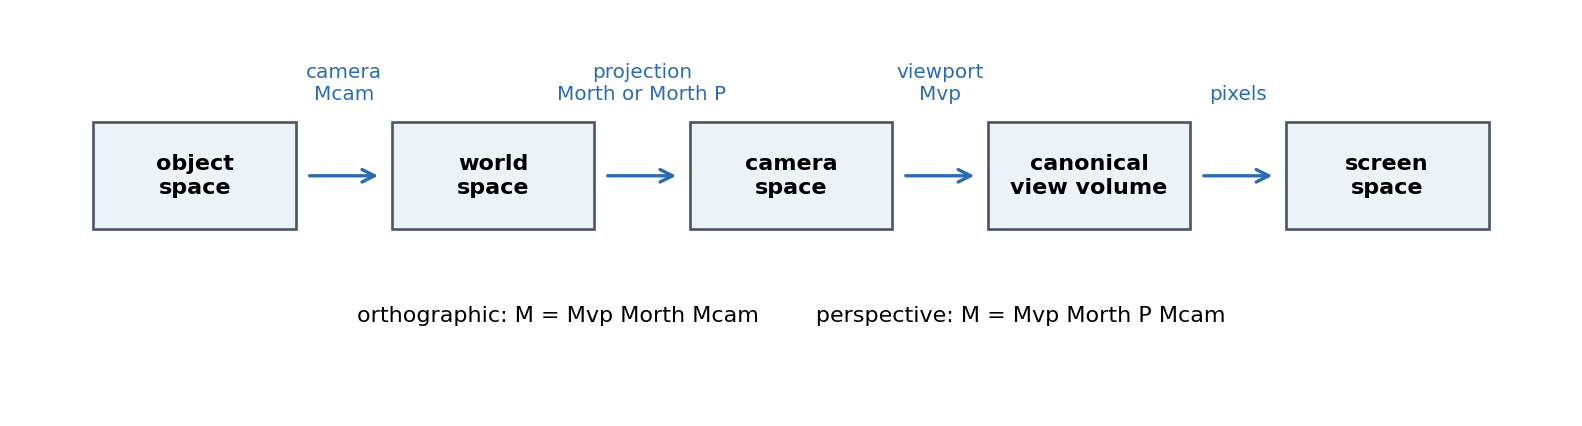

In [2]:
stages = [
    ("object\nspace", "modeling"),
    ("world\nspace", "camera\nMcam"),
    ("camera\nspace", "projection\nMorth or Morth P"),
    ("canonical\nview volume", "viewport\nMvp"),
    ("screen\nspace", "pixels"),
]

fig, ax = plt.subplots(figsize=(12.5, 3.2))
ax.set_xlim(-0.6, len(stages) - 0.4)
ax.set_ylim(-0.7, 1.0)
ax.axis("off")
for i, (stage, arrow_label) in enumerate(stages):
    rect = Rectangle((i - 0.34, 0.08), 0.68, 0.46, facecolor=COLORS["light"], edgecolor=COLORS["gray"], lw=1.2)
    ax.add_patch(rect)
    ax.text(i, 0.31, stage, ha="center", va="center", weight="bold")
    if i < len(stages) - 1:
        arrow = FancyArrowPatch((i + 0.37, 0.31), (i + 0.63, 0.31), arrowstyle="->", mutation_scale=14, lw=1.5, color=COLORS["blue"])
        ax.add_patch(arrow)
        ax.text(i + 0.5, 0.62, stages[i + 1][1], ha="center", va="bottom", color=COLORS["blue"], fontsize=9)
ax.text(2.0, -0.32, "orthographic: M = Mvp Morth Mcam        perspective: M = Mvp Morth P Mcam", ha="center", fontsize=10)
checks["pipeline_stage_count"] = len(stages)
checks["perspective_product_order"] = "Mvp Morth P Mcam"
chain_path = remember(save_matplotlib(fig, UNIT, "viewing-transform-chain.png"), "image")
plt.close(fig)
display_artifact(chain_path, width=900)


## 2. Viewport And Orthographic Projection Are Window Maps

A viewport matrix maps the canonical square `[-1,1]^2` to pixel-center coordinates. With the pixel-center convention, the left image boundary is at `-0.5`, the right boundary is at `nx - 0.5`, and similarly for `y`. The z-coordinate is carried along because later hidden-surface methods need depth even though wireframe drawing uses only x and y.

Orthographic projection is another windowing transformation, this time from an axis-aligned view box `[l,r] x [b,t] x [f,n]` into the canonical cube. In the chapter's right-handed convention the camera looks down negative z, so a typical near plane has `n = -1` and a far plane might have `f = -8`; the near value is greater than the far value. The check below verifies the corners and the near/far depth endpoints.


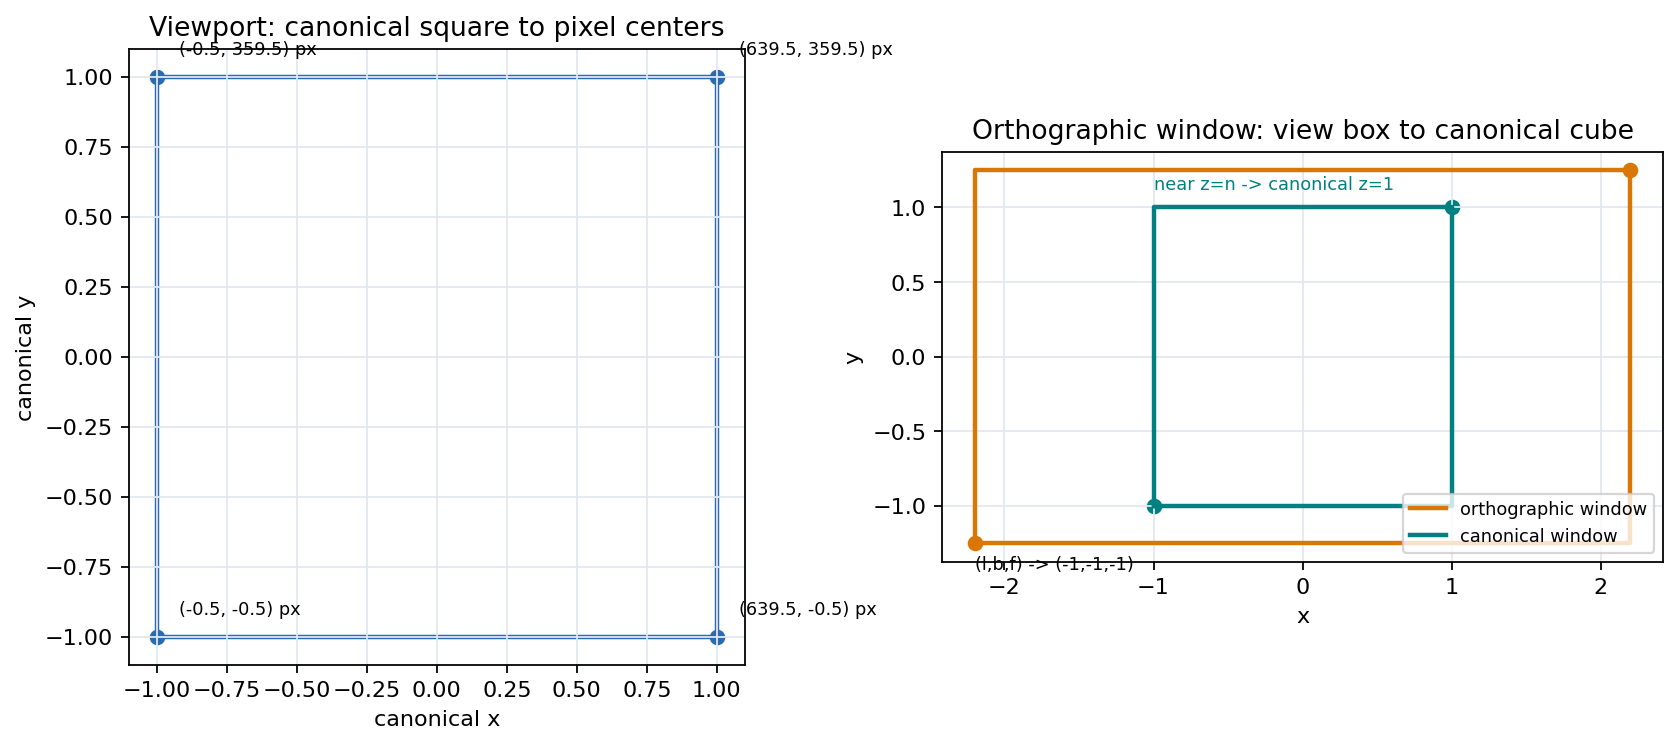

In [3]:
nx, ny = 640, 360
Mvp = viewport_matrix(nx, ny)
canonical_corners = np.array([[-1, -1, 0], [1, -1, 0], [1, 1, 0], [-1, 1, 0]])
pixel_corners = project_points(Mvp, canonical_corners)

l, r, b, t, n, f = -2.2, 2.2, -1.25, 1.25, -1.0, -8.0
Morth = orthographic_matrix(l, r, b, t, n, f)
ortho_test_points = np.array([[l, b, f], [r, t, n], [0, 0, (n + f) / 2]])
ortho_canonical = project_points(Morth, ortho_test_points)

checks["viewport_lower_left"] = [float(v) for v in pixel_corners[0, :2]]
checks["viewport_upper_right"] = [float(v) for v in pixel_corners[2, :2]]
checks["orthographic_corner_map"] = [float(v) for v in ortho_canonical[0]]
checks["orthographic_near_corner_map"] = [float(v) for v in ortho_canonical[1]]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0))
ax = axes[0]
ax.add_patch(Rectangle((-1, -1), 2, 2, fill=False, edgecolor=COLORS["blue"], lw=2, label="canonical square"))
for p, q in zip(canonical_corners, pixel_corners):
    ax.scatter(p[0], p[1], color=COLORS["blue"])
    ax.annotate(f"({q[0]:.1f}, {q[1]:.1f}) px", xy=(p[0], p[1]), xytext=(p[0] + 0.08, p[1] + 0.08), fontsize=8)
ax.set_aspect("equal")
style_2d(ax, "Viewport: canonical square to pixel centers", "canonical x", "canonical y")

ax = axes[1]
box_x = [l, r, r, l, l]
box_y = [b, b, t, t, b]
ax.plot(box_x, box_y, color=COLORS["orange"], lw=2, label="orthographic window")
ax.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], color=COLORS["teal"], lw=2, label="canonical window")
ax.scatter([l, r], [b, t], color=COLORS["orange"])
ax.scatter([-1, 1], [-1, 1], color=COLORS["teal"])
ax.text(l, b - 0.18, "(l,b,f) -> (-1,-1,-1)", fontsize=8)
ax.text(-1, 1.12, "near z=n -> canonical z=1", fontsize=8, color=COLORS["teal"])
ax.set_aspect("equal")
style_2d(ax, "Orthographic window: view box to canonical cube", "x", "y")
ax.legend(fontsize=8, loc="lower right")
viewport_path = remember(save_matplotlib(fig, UNIT, "viewport-orthographic-window-map.png"), "image")
plt.close(fig)
display_artifact(viewport_path, width=900)


## 3. The Camera Matrix Is A Basis Change

The camera is specified by an eye point `e`, a gaze vector `g`, and an up vector `t`. Those inputs are not yet a coordinate frame: `g` and `t` need not be perpendicular or unit length. The construction makes `w` point opposite the gaze, makes `u` perpendicular to the up-gaze plane, and then sets `v = w x u`. The matrix first translates the eye to the origin and then expresses coordinates in the `u,v,w` basis.

This visual is useful because many viewing bugs are basis bugs. A flipped cross product changes handedness. An unnormalized up vector is harmless if the basis is constructed correctly. A gaze vector parallel to the up vector is a genuine degeneracy and should be rejected by production code.


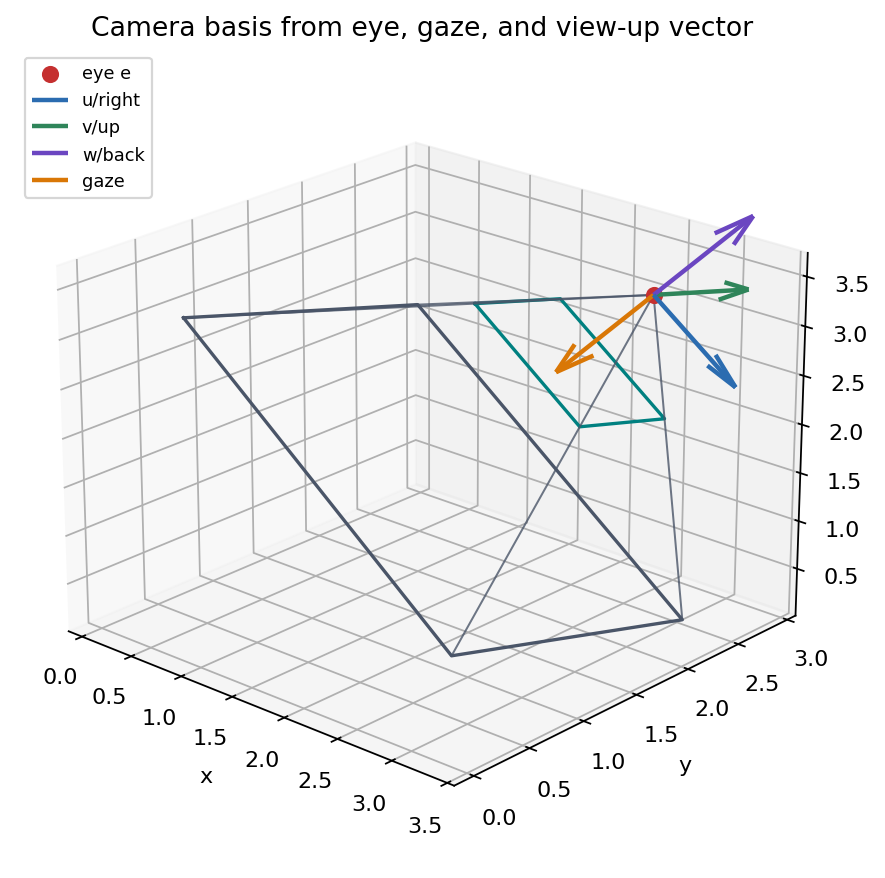

In [4]:
eye = np.array([3.0, 2.2, 3.5])
gaze = np.array([-2.6, -1.5, -3.8])
up = np.array([0.25, 1.0, 0.1])
u, v, w = camera_basis(eye, gaze, up)
Mcam = camera_matrix(eye, gaze, up)
frame = np.vstack([u, v, w])
checks["camera_basis_dot_max"] = float(np.max(np.abs(frame @ frame.T - np.eye(3))))
checks["camera_basis_determinant"] = float(np.linalg.det(frame))
checks["camera_eye_maps_to_origin_norm"] = float(np.linalg.norm(apply_matrix(Mcam, eye)[:3]))

fig = plt.figure(figsize=(8.0, 6.6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter([eye[0]], [eye[1]], [eye[2]], color=COLORS["red"], s=45, label="eye e")
for vec, name, color in [(u, "u/right", COLORS["blue"]), (v, "v/up", COLORS["green"]), (w, "w/back", COLORS["purple"]), (normalize(gaze), "gaze", COLORS["orange"] )]:
    ax.quiver(eye[0], eye[1], eye[2], vec[0], vec[1], vec[2], length=1.05, normalize=True, color=color, linewidth=2, label=name)
# draw a small perspective frustum in world coordinates
near, far = 0.9, 2.4
half_h = 0.45
half_w = 0.7
centers = [eye + normalize(gaze) * near, eye + normalize(gaze) * far]
near_corners = np.array([centers[0] + sx * half_w * u + sy * half_h * v for sx, sy in [(-1,-1),(1,-1),(1,1),(-1,1)]])
far_corners = np.array([centers[1] + sx * half_w * far/near * u + sy * half_h * far/near * v for sx, sy in [(-1,-1),(1,-1),(1,1),(-1,1)]])
for corners, color in [(near_corners, COLORS["teal"]), (far_corners, COLORS["gray"] )]:
    loop = np.r_[corners, corners[:1]]
    ax.plot(loop[:,0], loop[:,1], loop[:,2], color=color, lw=1.5)
for a, bpt in zip(near_corners, far_corners):
    ax.plot([eye[0], bpt[0]], [eye[1], bpt[1]], [eye[2], bpt[2]], color=COLORS["gray"], lw=0.9, alpha=0.8)
ax.set_title("Camera basis from eye, gaze, and view-up vector")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(fontsize=8, loc="upper left")
ax.view_init(elev=22, azim=-48)
camera_path = remember(save_matplotlib(fig, UNIT, "camera-uvw-basis-frustum.png"), "image")
plt.close(fig)
display_artifact(camera_path, width=760)


## 4. Projective Transforms Use The Homogeneous Coordinate As A Denominator

Affine transformations keep the bottom row of a homogeneous matrix equal to `[0,0,0,1]`, so the `w` coordinate stays one. Viewing needs more: perspective size changes require a denominator that depends on depth. Once `w` is allowed to change, a matrix can represent linear rational functions. The final Cartesian coordinates are read only after the homogeneous divide.

The square-to-quadrilateral example below demonstrates the key qualitative properties. Straight edges stay straight, but parallel edges need not remain parallel. Multiplying either the input homogeneous vector or the matrix by a nonzero scalar does not change the represented point after division.


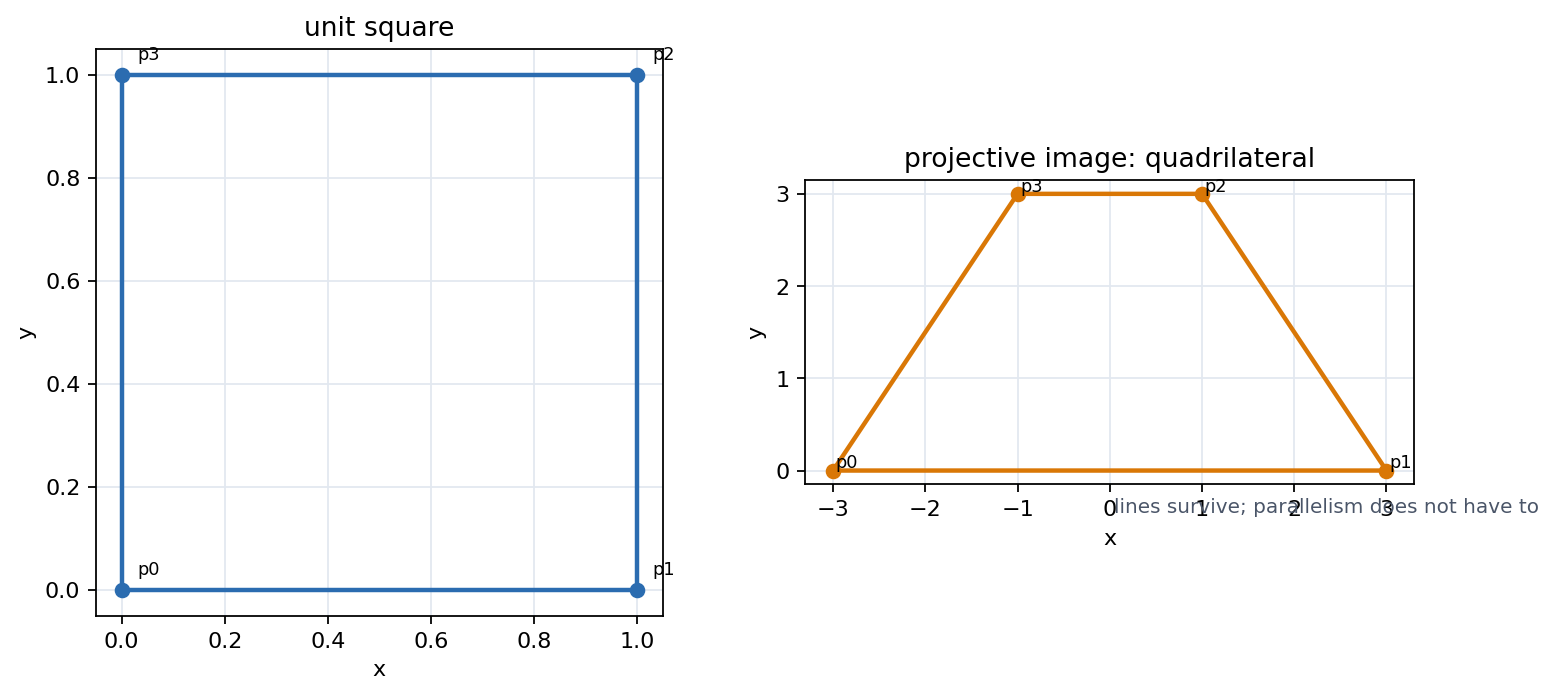

In [5]:
H2 = np.array([
    [2.0, 0.0, -1.0],
    [0.0, 3.0, 0.0],
    [0.0, 2.0 / 3.0, 1.0 / 3.0],
])
square = np.array([[0,0], [1,0], [1,1], [0,1]])
square_h = np.c_[square, np.ones(4)]
quad_h = (H2 @ square_h.T).T
quad = quad_h[:, :2] / quad_h[:, 2:]
scaled_residual = np.linalg.norm((3 * H2 @ (5 * square_h[1]).T)[:2] / (3 * H2 @ (5 * square_h[1]).T)[2] - quad[1])
checks["homogeneous_scalar_equivalence_residual"] = float(scaled_residual)
checks["projective_square_parallelism_changes"] = bool(abs((quad[1,1]-quad[0,1]) - (quad[2,1]-quad[3,1])) > 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.6))
for ax, pts, title, color in [(axes[0], square, "unit square", COLORS["blue"]), (axes[1], quad, "projective image: quadrilateral", COLORS["orange"] )]:
    loop = np.r_[pts, pts[:1]]
    ax.plot(loop[:,0], loop[:,1], color=color, lw=2)
    ax.scatter(pts[:,0], pts[:,1], color=color, zorder=3)
    for i, p in enumerate(pts):
        ax.text(p[0] + 0.03, p[1] + 0.03, f"p{i}", fontsize=8)
    ax.set_aspect("equal", adjustable="box")
    style_2d(ax, title, "x", "y")
axes[1].text(0.05, -0.45, "lines survive; parallelism does not have to", fontsize=9, color=COLORS["gray"])
projective_path = remember(save_matplotlib(fig, UNIT, "homogeneous-projective-square-map.png"), "image")
plt.close(fig)
display_artifact(projective_path, width=820)


## 5. Perspective Projection Maps A Frustum To The Orthographic Box

The perspective matrix `P` is the chapter's clever bridge. It maps the perspective view volume into an orthographic view volume, after which the familiar orthographic window map can finish the job. On the near plane `z = n`, the matrix leaves `x` and `y` unchanged after the homogeneous divide. On the far plane `z = f`, it scales the back rectangle down to match the near-plane window while preserving the far depth value.

The nonlinear part is depth. The transformed depth has the form `z' = n + f - fn/z`. It is not a linear map of z, but it preserves ordering inside the view volume. That fact is why later z-buffering can compare transformed depth values after perspective projection, provided geometry has been clipped so it does not cross the eye plane.


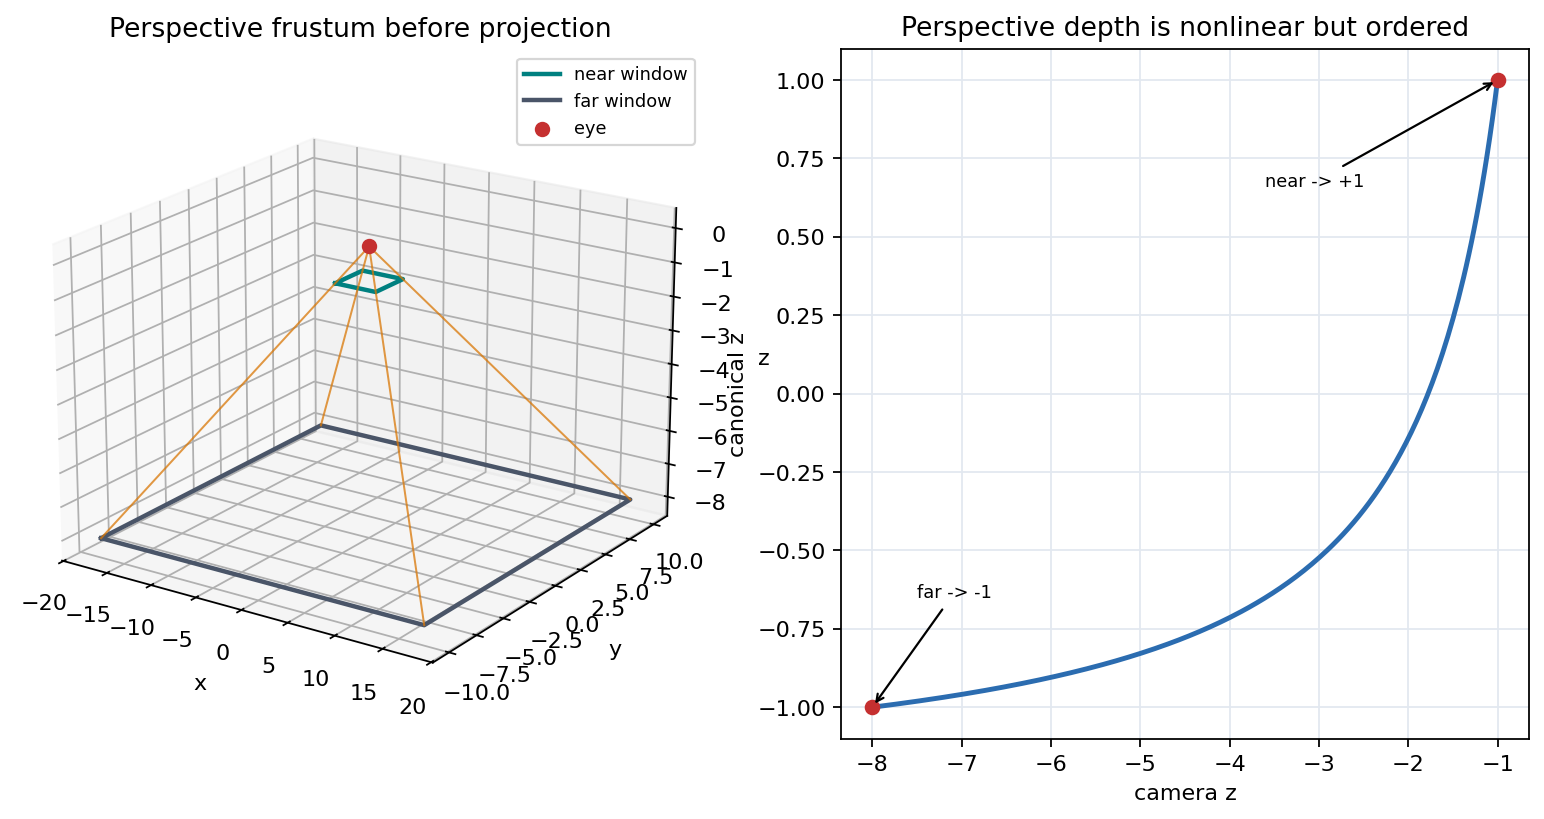

In [6]:
P = perspective_matrix(n, f)
Mper = Morth @ P
near_corners_cam = np.array([[l,b,n], [r,b,n], [r,t,n], [l,t,n]])
far_scale = f / n
far_corners_cam = np.array([[l*far_scale,b*far_scale,f], [r*far_scale,b*far_scale,f], [r*far_scale,t*far_scale,f], [l*far_scale,t*far_scale,f]])
near_after = project_points(Mper, near_corners_cam)
far_after = project_points(Mper, far_corners_cam)
checks["perspective_near_corner_residual"] = float(np.linalg.norm(near_after[2] - np.array([1,1,1])))
checks["perspective_far_corner_residual"] = float(np.linalg.norm(far_after[0] - np.array([-1,-1,-1])))

z_values = np.linspace(f, n, 240)
z_prime = n + f - (f * n) / z_values
canonical_z = (2 * z_prime - (n + f)) / (n - f)
checks["perspective_depth_monotone"] = bool(np.all(np.diff(canonical_z) > 0))

fig = plt.figure(figsize=(12.2, 5.6))
ax3 = fig.add_subplot(121, projection="3d")
for corners, color, name in [(near_corners_cam, COLORS["teal"], "near window"), (far_corners_cam, COLORS["gray"], "far window")]:
    loop = np.r_[corners, corners[:1]]
    ax3.plot(loop[:,0], loop[:,1], loop[:,2], color=color, lw=2, label=name)
for a, bpt in zip(near_corners_cam, far_corners_cam):
    ax3.plot([0, bpt[0]], [0, bpt[1]], [0, bpt[2]], color=COLORS["orange"], lw=0.9, alpha=0.75)
ax3.scatter([0], [0], [0], color=COLORS["red"], s=35, label="eye")
ax3.set_title("Perspective frustum before projection")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")
ax3.legend(fontsize=8)
ax3.view_init(elev=20, azim=-56)

ax = fig.add_subplot(122)
ax.plot(z_values, canonical_z, color=COLORS["blue"], lw=2.2)
ax.scatter([f, n], [-1, 1], color=COLORS["red"], zorder=3)
ax.annotate("far -> -1", xy=(f, -1), xytext=(f + 0.5, -0.65), arrowprops={"arrowstyle":"->"}, fontsize=8)
ax.annotate("near -> +1", xy=(n, 1), xytext=(n - 2.6, 0.66), arrowprops={"arrowstyle":"->"}, fontsize=8)
style_2d(ax, "Perspective depth is nonlinear but ordered", "camera z", "canonical z")
perspective_path = remember(save_matplotlib(fig, UNIT, "perspective-frustum-depth-map.png"), "image")
plt.close(fig)
display_artifact(perspective_path, width=900)


## 6. Perspective Preserves Lines After Homogeneous Division

A projective transformation maps lines to lines. That statement is easy to misuse because the parameter along the line is not generally preserved. A point sampled halfway in 3D does not have to land halfway between the projected endpoints. What survives is collinearity and order, as long as the homogeneous coordinate does not change sign on the segment.

The artifact samples a slanted segment inside the frustum, applies the full perspective-to-canonical matrix, performs the homogeneous divide, and checks the signed area of each projected sample against the projected endpoints. The residual should be near zero.


C:\Users\rahul\AppData\Local\Temp\ipykernel_13248\727579969.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  area_residuals.append(abs(np.cross(line_vec, p2 - A2)))


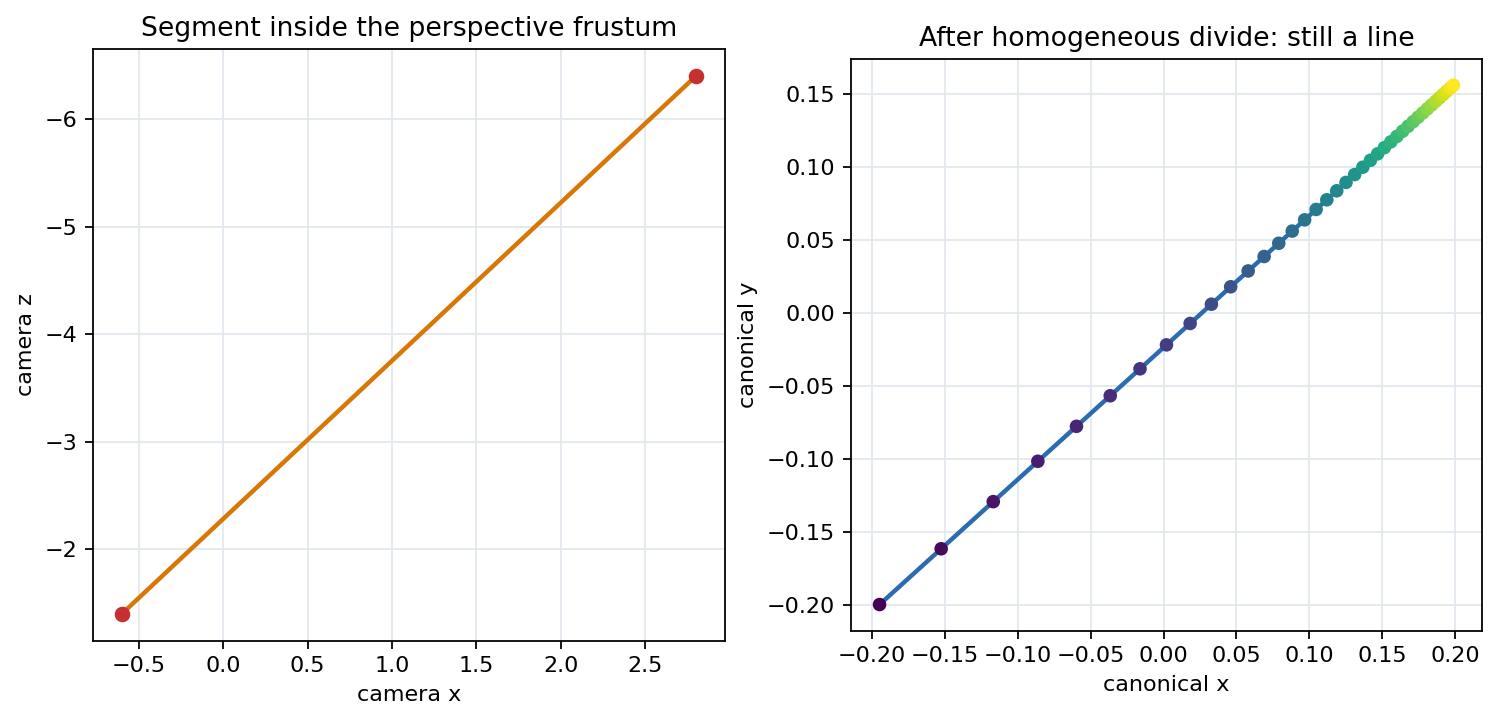

In [7]:
A = np.array([-0.6, -0.35, -1.4])
B = np.array([2.8, 1.25, -6.4])
ts = np.linspace(0, 1, 40)
segment = A[None, :] + ts[:, None] * (B - A)[None, :]
projected = project_points(Mper, segment)
A2, B2 = projected[0, :2], projected[-1, :2]
line_vec = B2 - A2
area_residuals = []
for p2 in projected[:, :2]:
    area_residuals.append(abs(np.cross(line_vec, p2 - A2)))
area_residuals = np.array(area_residuals)
# The projective line parameter from the text's formula is monotone when w keeps one sign.
transformed_h = apply_matrix(Mper, segment)
w_values = transformed_h[:, -1]
projective_parameter = (w_values[-1] * ts) / (w_values[0] + ts * (w_values[-1] - w_values[0]))
checks["line_preservation_area_residual_max"] = float(area_residuals.max())
checks["line_projective_parameter_monotone"] = bool(np.all(np.diff(projective_parameter) > 0))
checks["line_homogeneous_w_keeps_sign"] = bool(np.all(w_values < 0) or np.all(w_values > 0))

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8))
axes[0].plot(segment[:,0], segment[:,2], color=COLORS["orange"], lw=2)
axes[0].scatter([A[0], B[0]], [A[2], B[2]], color=COLORS["red"], zorder=3)
style_2d(axes[0], "Segment inside the perspective frustum", "camera x", "camera z")
axes[0].invert_yaxis()
axes[1].plot(projected[:,0], projected[:,1], color=COLORS["blue"], lw=2)
axes[1].scatter(projected[:,0], projected[:,1], c=ts, cmap="viridis", s=26, zorder=3)
style_2d(axes[1], "After homogeneous divide: still a line", "canonical x", "canonical y")
axes[1].set_aspect("equal", adjustable="box")
line_path = remember(save_matplotlib(fig, UNIT, "line-preservation-homogeneous-divide.png"), "image")
plt.close(fig)
display_artifact(line_path, width=850)


## Applied lab: field-of-view and aspect ratio

A centered perspective view can be specified by a vertical field-of-view angle, the near-plane distance, and the pixel aspect convention. With square pixels, the near-plane half-height is `|n| tan(theta/2)` and the half-width is that value multiplied by `nx/ny`. The lab below turns this into a surface: increasing field-of-view opens the frustum quickly, while increasing aspect ratio widens the window without changing its height.

The lab is also a design warning. A very wide FOV creates strong perspective distortion and can make straight objects near the edge of the image look stretched. That is not a bug in the perspective matrix; it is a consequence of asking a finite rectangle to represent a large angle from a single eye point.


In [8]:
fov_degrees = np.linspace(25, 110, 90)
aspects = np.linspace(0.75, 2.4, 80)
FOV, ASPECT = np.meshgrid(fov_degrees, aspects)
near_abs = abs(n)
half_height = near_abs * np.tan(np.radians(FOV) / 2)
half_width = ASPECT * half_height
checks["fov_half_height_60deg"] = float(near_abs * math.tan(math.radians(60) / 2))
checks["fov_width_monotone_in_angle"] = bool(np.all(np.diff(half_width[20, :]) > 0))
checks["fov_width_monotone_in_aspect"] = bool(np.all(np.diff(half_width[:, 30]) > 0))

fig_lab = go.Figure(data=[go.Surface(x=FOV, y=ASPECT, z=2 * half_width, colorscale="Viridis")])
fig_lab.update_layout(
    title="Near-plane window width from field-of-view and aspect ratio",
    scene=dict(xaxis_title="vertical FOV degrees", yaxis_title="aspect nx/ny", zaxis_title="near-plane width"),
    height=560,
)
fov_path = remember(save_plotly_html(fig_lab, UNIT, "field-of-view-frustum-lab.html", include_plotlyjs=True), "html")
display_artifact(fov_path, width="100%", height=560)


## Display the chapter artifacts

The generated files live under `artifacts/chapter-08`, not in a shared bootstrap folder. The filenames name the viewing concept they teach so stale references are easy to spot during review.


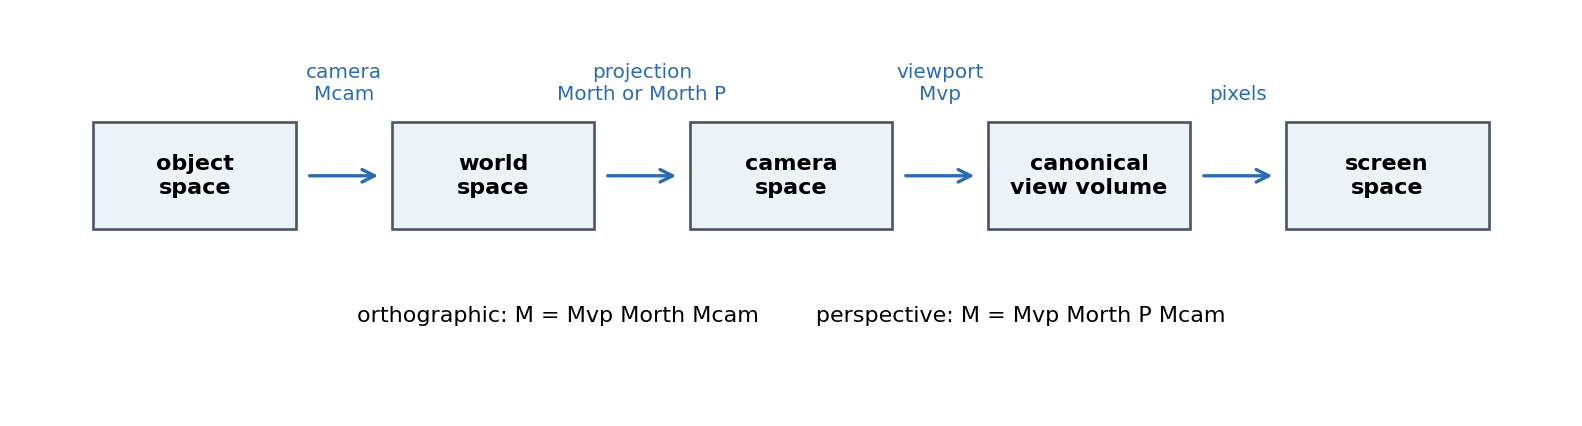

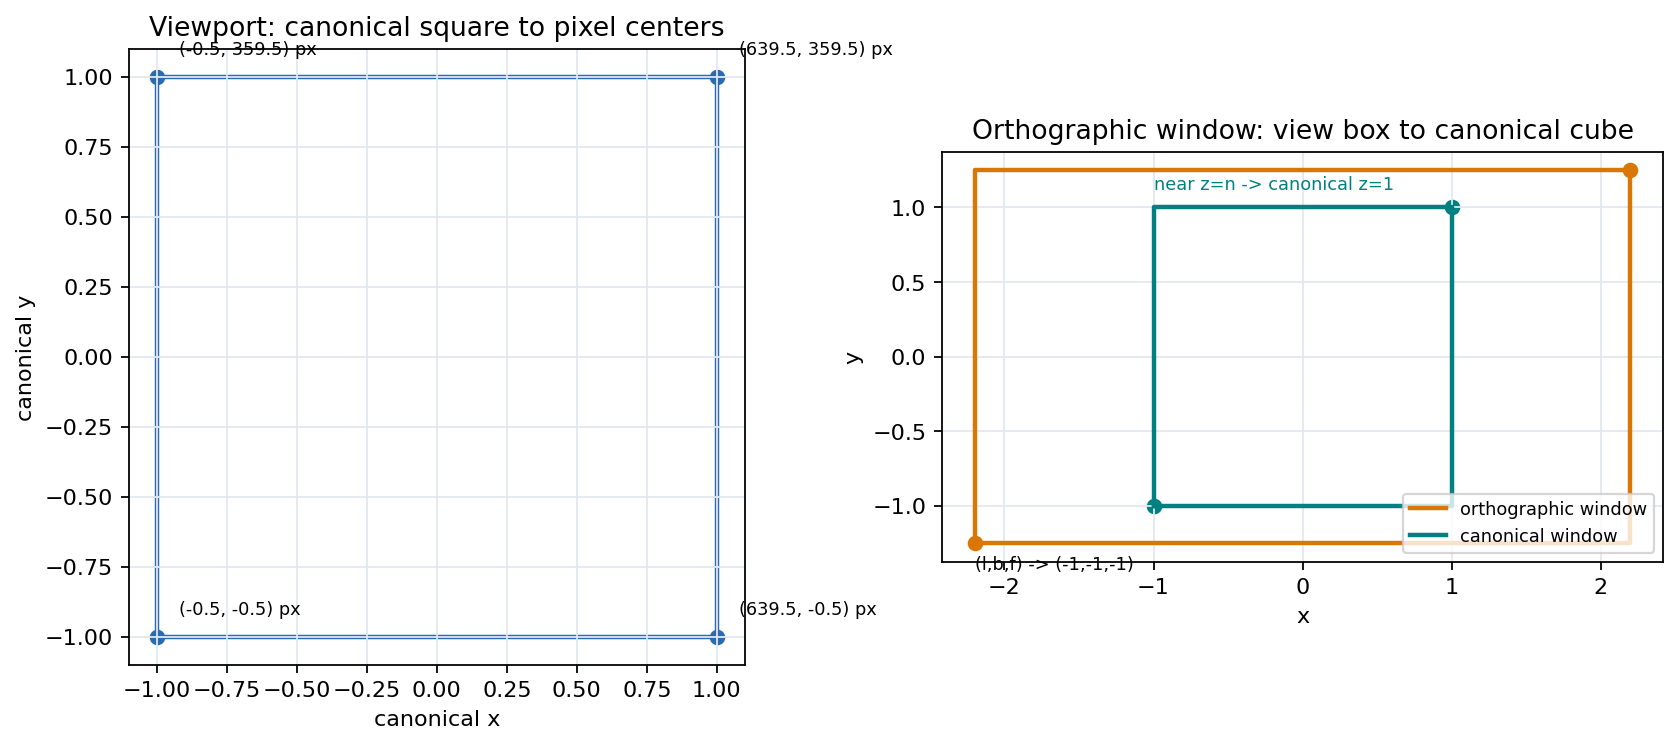

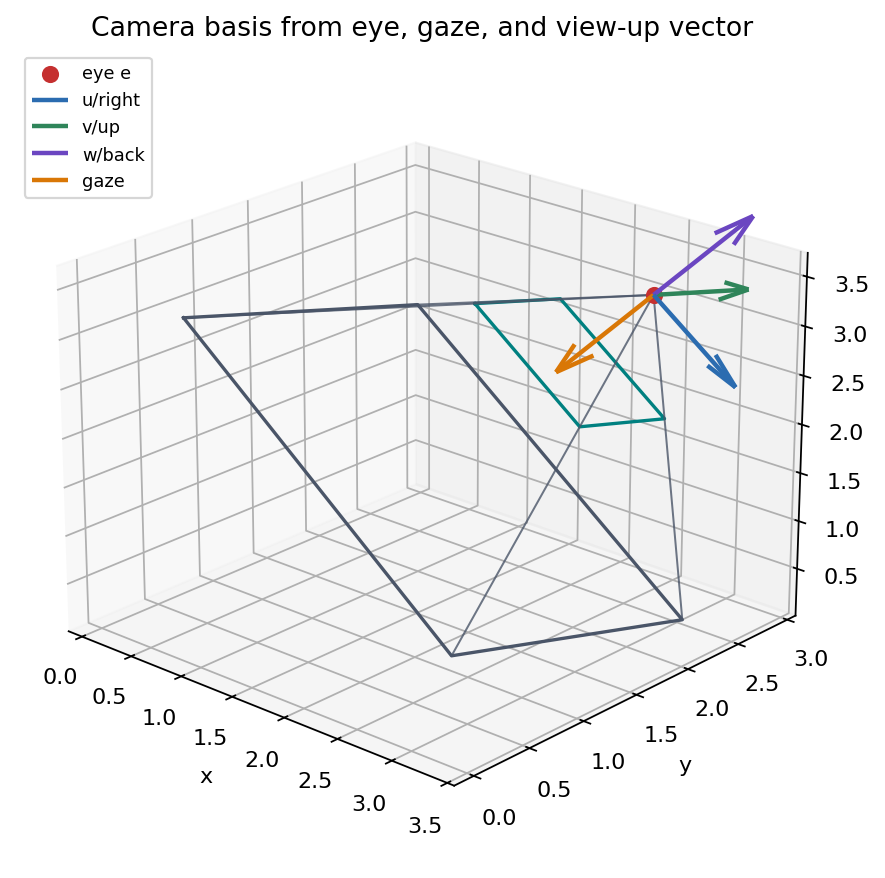

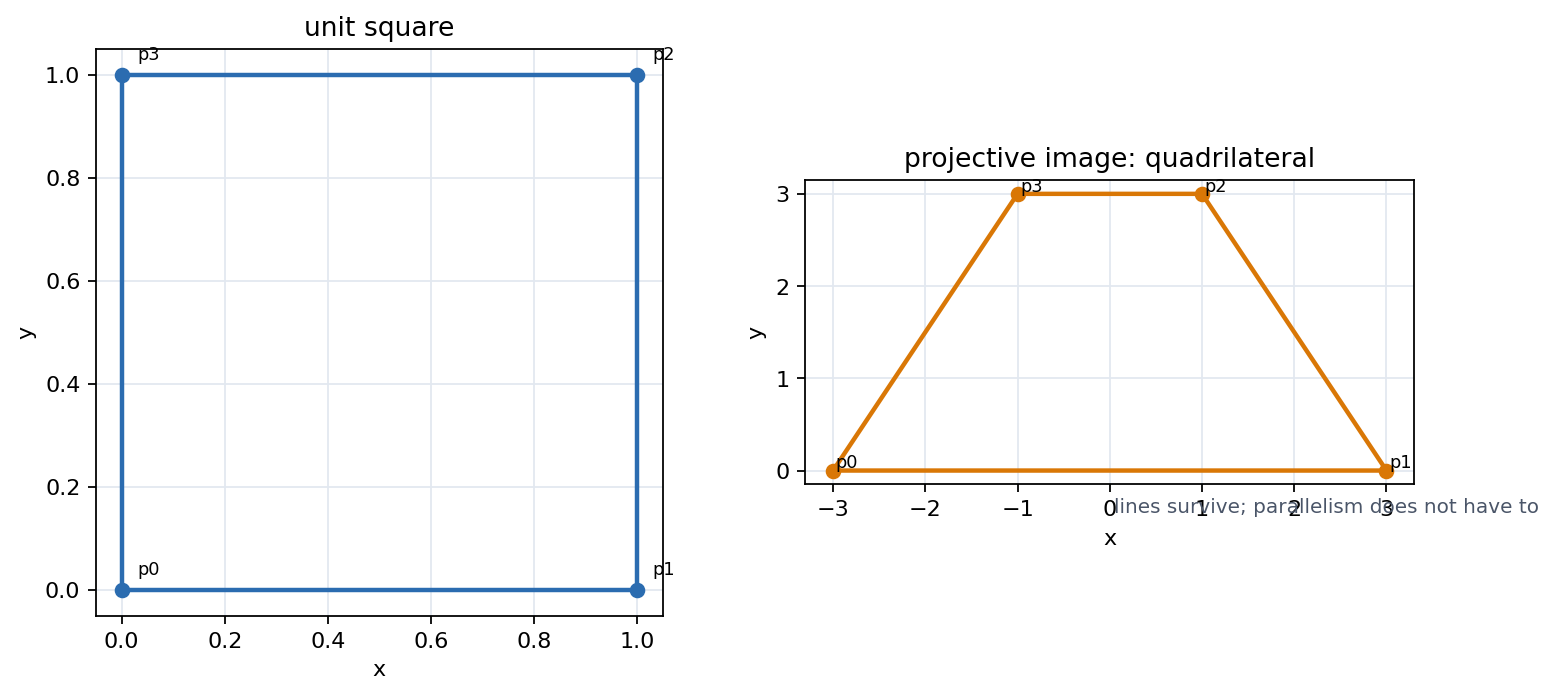

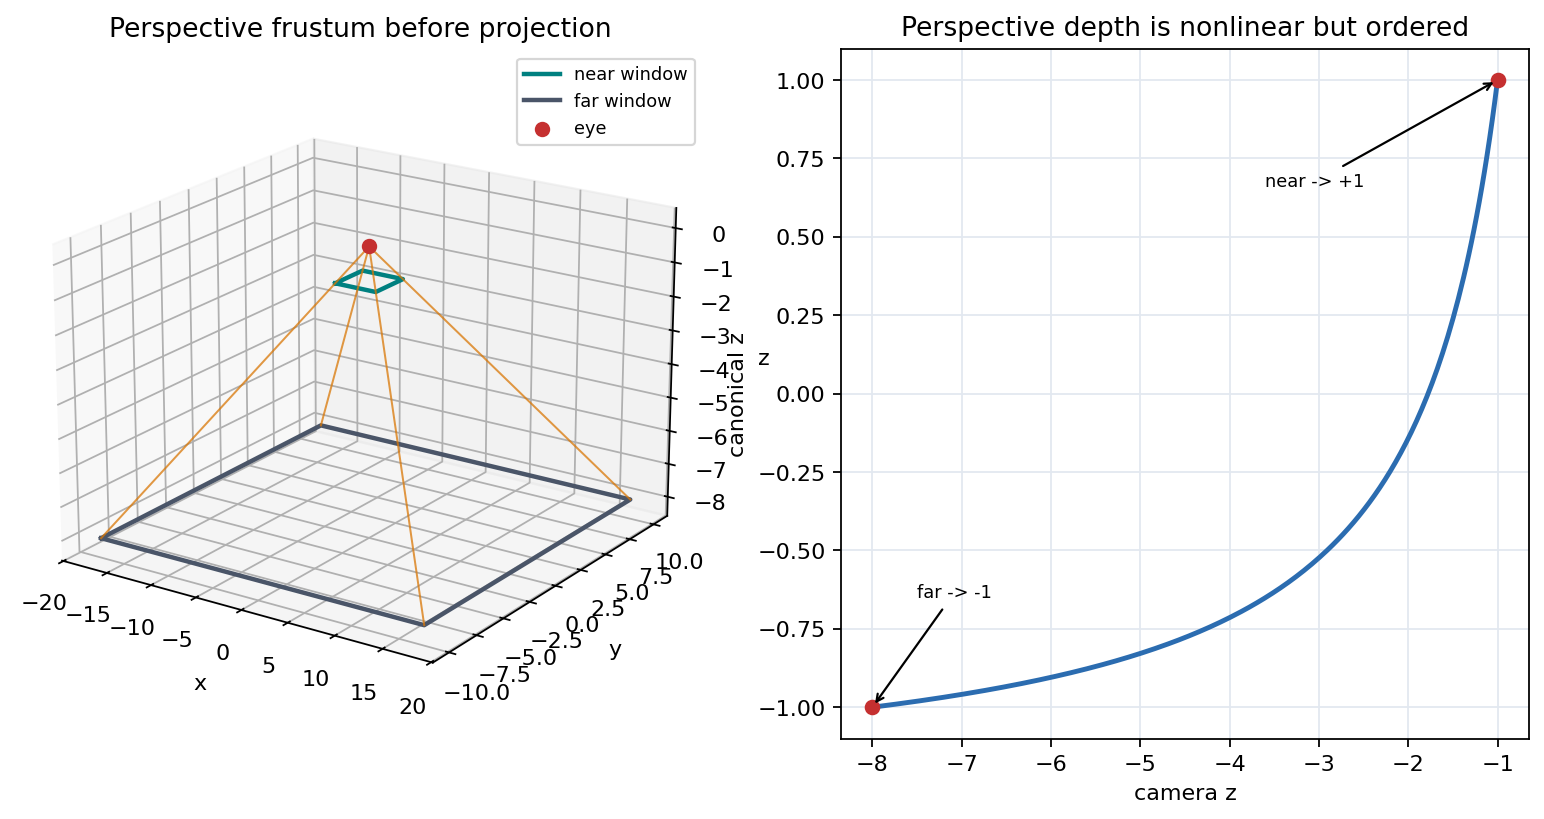

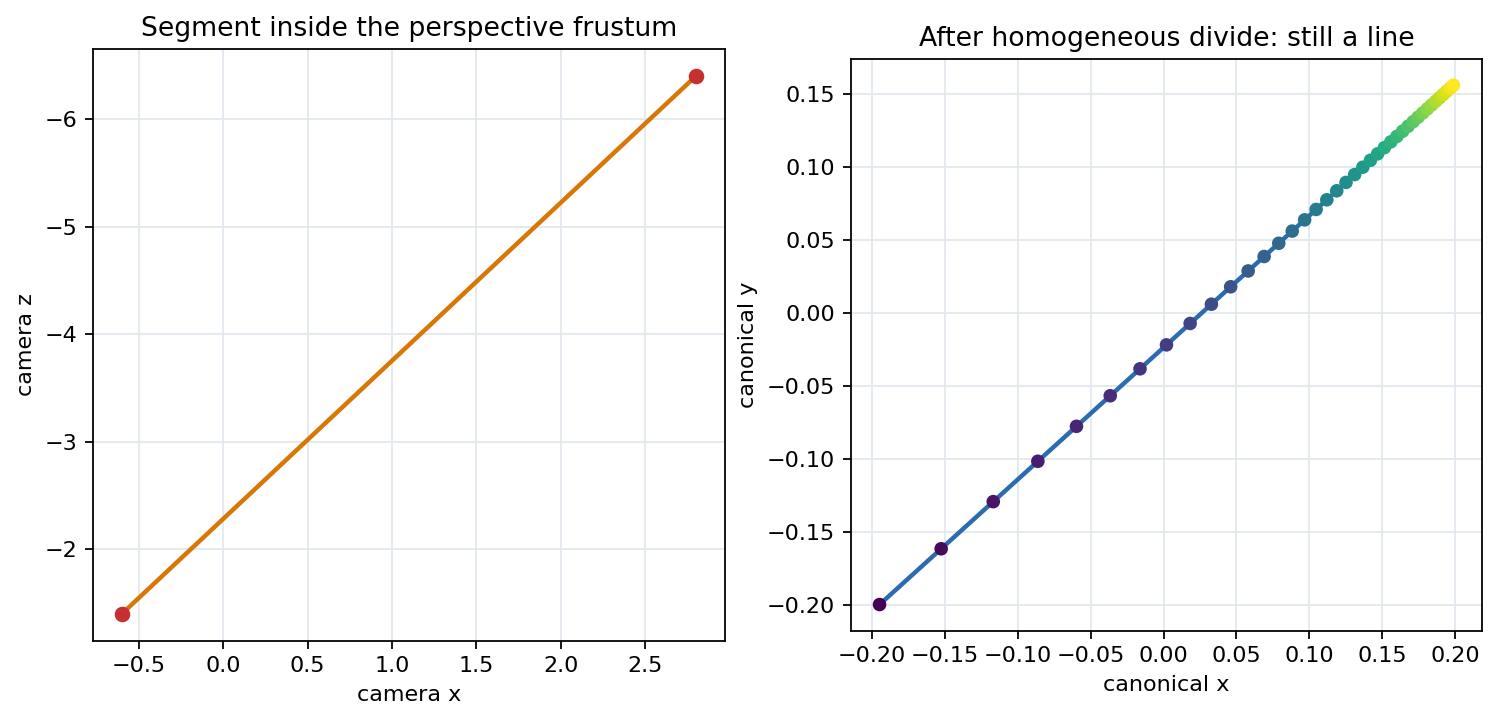

In [9]:
artifact_sequence = [*image_paths, *html_paths]
assert_artifacts(artifact_sequence)
for path in image_paths:
    display_artifact(path, width=760)
for path in html_paths:
    display_artifact(path, width="100%", height=560)


## Sanity checks

The checks are tied to the viewing chapter's main invariants: viewport endpoints, orthographic window endpoints, camera-basis orthonormality, homogeneous scale equivalence, perspective frustum corners, depth monotonicity, line preservation, and field-of-view formulas. They do not claim to implement clipping or hidden-surface removal; those topics belong to the next chapter. Here the aim is narrower: make the matrices and the homogeneous divide inspectable before they are embedded in the full rasterization pipeline.


In [10]:
assert np.allclose(checks["viewport_lower_left"], [-0.5, -0.5])
assert np.allclose(checks["viewport_upper_right"], [nx - 0.5, ny - 0.5])
assert np.allclose(checks["orthographic_corner_map"], [-1, -1, -1])
assert np.allclose(checks["orthographic_near_corner_map"], [1, 1, 1])
assert checks["camera_basis_dot_max"] < 1e-12
assert abs(checks["camera_basis_determinant"] - 1.0) < 1e-12
assert checks["camera_eye_maps_to_origin_norm"] < 1e-12
assert checks["homogeneous_scalar_equivalence_residual"] < 1e-12
assert checks["perspective_near_corner_residual"] < 1e-12
assert checks["perspective_far_corner_residual"] < 1e-12
assert checks["perspective_depth_monotone"] is True
assert checks["line_preservation_area_residual_max"] < 1e-10
assert checks["line_projective_parameter_monotone"] is True
assert checks["line_homogeneous_w_keeps_sign"] is True
assert checks["fov_width_monotone_in_angle"] is True
assert checks["fov_width_monotone_in_aspect"] is True

image_records = [assert_nonblank_image(path) for path in image_paths]
artifact_records = assert_artifacts([*image_paths, *html_paths])
check_rows = [
    {"check": key, "value": str(value), "concept": "viewing matrix invariant"}
    for key, value in sorted(checks.items())
]
table_path = remember(save_table_csv(check_rows, UNIT, "viewing-matrix-check-ledger.csv"), "table")

storyboard = {
    "chapter": CHAPTER,
    "title": TITLE,
    "source_span": SOURCE_SPAN,
    "visuals": [rel_book(path) for path in image_paths + html_paths + [table_path]],
    "library_routing": {
        "matplotlib": "static matrix diagrams, camera/frustum view, projective-map diagnostics, and line-preservation checks",
        "plotly": "interactive field-of-view/aspect-ratio surface",
        "numpy": "matrix construction, homogeneous coordinates, basis checks, and residuals",
    },
    "checks": checks,
}
storyboard_path = remember(save_json(storyboard, UNIT, "visual-storyboard.json"), "check")
checks_path = remember(save_json({"chapter": CHAPTER, "checks": checks, "image_records": image_records}, UNIT, "viewing-invariants.json"), "check")
numeric_path = remember(save_json({"chapter": CHAPTER, "checks": checks}, UNIT, "numeric-checks.json"), "check")
final_report = {
    "chapter": CHAPTER,
    "title": TITLE,
    "printed_pages": "157-176",
    "pdf_pages": "174-193",
    "artifacts": [rel_book(path) for path in image_paths + html_paths + table_paths + check_paths],
    "nonblank_images": len(image_records),
    "checks": checks,
    "notebook_executed": True,
}
final_path = remember(save_json(final_report, UNIT, "final-sanity.json"), "check")
assert_artifacts([*check_paths, table_path])
display_artifact(final_path)
final_report


{'chapter': 8,
 'title': 'Viewing',
 'printed_pages': '157-176',
 'pdf_pages': '174-193',
 'artifacts': ['artifacts/chapter-08/figures/viewing-transform-chain.png',
  'artifacts/chapter-08/figures/viewport-orthographic-window-map.png',
  'artifacts/chapter-08/figures/camera-uvw-basis-frustum.png',
  'artifacts/chapter-08/figures/homogeneous-projective-square-map.png',
  'artifacts/chapter-08/figures/perspective-frustum-depth-map.png',
  'artifacts/chapter-08/figures/line-preservation-homogeneous-divide.png',
  'artifacts/chapter-08/html/field-of-view-frustum-lab.html',
  'artifacts/chapter-08/tables/viewing-matrix-check-ledger.csv',
  'artifacts/chapter-08/checks/visual-storyboard.json',
  'artifacts/chapter-08/checks/viewing-invariants.json',
  'artifacts/chapter-08/checks/numeric-checks.json'],
 'nonblank_images': 6,
 'checks': {'pipeline_stage_count': 5,
  'perspective_product_order': 'Mvp Morth P Mcam',
  'viewport_lower_left': [-0.5, -0.5],
  'viewport_upper_right': [639.5, 359.5]

## Takeaways

- Viewing is a sequence of coordinate changes, not a single magic formula.
- The viewport transform is a 2D window map with pixel-center conventions; the orthographic transform is the same idea in a 3D view box.
- The camera transform is a rigid basis change built from `eye`, `gaze`, and `up`; the cross-product order controls handedness.
- Perspective becomes matrix-friendly when homogeneous `w` is allowed to change and the Cartesian coordinates are read after division.
- The perspective matrix does not preserve z linearly, but it preserves depth order inside a clipped view volume.
- A centered field-of-view specification is just a way to compute the near-plane window before building the general perspective matrix.
